In [1]:
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
import pickle

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.25)

In [3]:
import medmnist
from medmnist import INFO, Evaluator

In [4]:
# Import local files
%load_ext autoreload
%autoreload 2
from cnn_training import *
from plots import *
from cnn import *
from constants import *

In [5]:
data_flag = 'dermamnist'
download = True

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

In [6]:
info

{'python_class': 'DermaMNIST',
 'description': 'The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/dermamnist.npz?download=1',
 'MD5': '0744692d530f8e62ec473284d019b0c7',
 'url_64': 'https://zenodo.org/records/10519652/files/dermamnist_64.npz?download=1',
 'MD5_64': 'b70a2f5635c6199aeaa28c31d7202e1f',
 'url_128': 'https://zenodo.org/records/10519652/files/dermamnist_128.npz?download=1',
 'MD5_128': '2defd784463fa5243564e855ed717de1',
 'url_224': 'https://zenodo.org/records/10519652/files/dermamnist_224.npz?download=1',
 'MD5_224': '8974907d8e169bef5f5b96bc506ae45d',
 'task': 'multi-c

In [7]:
# Note: this preprocesses data such that it has mean 0.5 and std dev 0.5.
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

BATCH_SIZE = 128

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
# train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

In [8]:
def default_setup_cnn(lr=0.001, l2_weight=0.0):
    model = CNN(n_channels, n_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=l2_weight)
    return model, criterion, optimizer

## Fully Labeled Dataset
What kind of performance can we get if we leave all labels in the dataset?
This might be helpful just to view as an upper bound, like our best possible performance

In [24]:
cnn_labeled, criterion, optimizer = default_setup()
np.random.seed(42)  # reset after get_semi_supervised_labels
torch.manual_seed(42)

train_history = train_loop_labeled(cnn_labeled, train_loader, val_loader, criterion, optimizer, num_epochs=20)

100%|██████████| 55/55 [00:04<00:00, 13.09it/s]


Epoch 1/20 | Train Loss: 0.9478 | Val Loss: 0.8331 | Val AUC Macro: 0.8584 | Val AUC Global: 0.9420


100%|██████████| 55/55 [00:04<00:00, 13.12it/s]


Epoch 2/20 | Train Loss: 0.8039 | Val Loss: 0.7584 | Val AUC Macro: 0.8887 | Val AUC Global: 0.9522


100%|██████████| 55/55 [00:04<00:00, 13.11it/s]


...

Epoch 18/20 | Train Loss: 0.3665 | Val Loss: 0.8399 | Val AUC Macro: 0.9181 | Val AUC Global: 0.9593


100%|██████████| 55/55 [00:04<00:00, 13.05it/s]


Epoch 19/20 | Train Loss: 0.3172 | Val Loss: 0.8321 | Val AUC Macro: 0.9088 | Val AUC Global: 0.9551


100%|██████████| 55/55 [00:04<00:00, 13.05it/s]


Epoch 20/20 | Train Loss: 0.3025 | Val Loss: 0.8504 | Val AUC Macro: 0.9159 | Val AUC Global: 0.9581


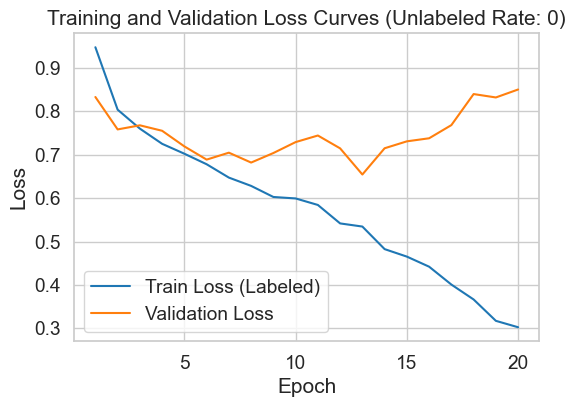

In [25]:
plot_loss_curves(train_history)

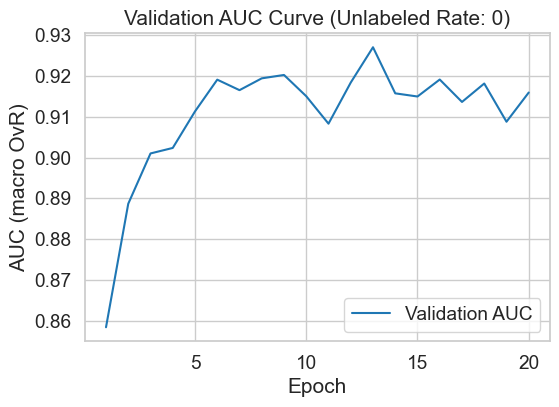

In [26]:
plot_auc_curve(train_history)

In [27]:
best = max(train_history, key=lambda x: x['val_auc_macro'])
print(f"Best Epoch: {best['epoch']} | Val AUC: {best['val_auc_macro']:.4f} | Val Loss: {best['val_loss']:.4f}")

best_model_upper_bound = CNN(n_channels, n_classes)
best_model_upper_bound.load_state_dict(best['model_state'])

Best Epoch: 13 | Val AUC: 0.9270 | Val Loss: 0.6545


<All keys matched successfully>

In [28]:
test_metrics = evaluate(best_model_upper_bound, test_loader)
print(f"Test AUC Macro: {test_metrics['macro_auc']:.4f} | Test AUC Global: {test_metrics['global_auc']:.4f}")
print(f"Test Macro NLL: {test_metrics['macro_nll']:.4f} | Test Per-Class NLL: {test_metrics['per_class_nll']}")

Test AUC Macro: 0.9239 | Test AUC Global: 0.9649
Test Macro NLL: 1.4823 | Test Per-Class NLL: [1.8980656  1.4777851  1.4497406  2.639275   1.5621701  0.20537274
 1.1434988 ]


In [61]:
class_probs = [[] for _ in range(7)]
with torch.no_grad():
    best_model_upper_bound.eval()
    for images, labels in train_loader:
        outputs = best_model_upper_bound(images)
        probs = torch.softmax(outputs, dim=1)
        for i in range(7):
            mask = (labels.squeeze() == i)
            if mask.sum() > 0:
                class_probs[i].append(probs[mask])

for i in range(7):
    if class_probs[i]:
        mean_dist = torch.cat(class_probs[i]).mean(dim=0).numpy()
        print(f"Class {i}: {np.round(mean_dist, 3)}")

Class 0: [0.474 0.235 0.119 0.021 0.106 0.043 0.002]
Class 1: [0.053 0.655 0.069 0.036 0.056 0.073 0.057]
Class 2: [0.027 0.06  0.54  0.008 0.145 0.215 0.005]
Class 3: [0.043 0.275 0.077 0.358 0.039 0.156 0.053]
Class 4: [0.017 0.019 0.081 0.002 0.701 0.177 0.004]
Class 5: [0.003 0.011 0.04  0.002 0.089 0.851 0.005]
Class 6: [0.    0.016 0.01  0.002 0.037 0.085 0.85 ]


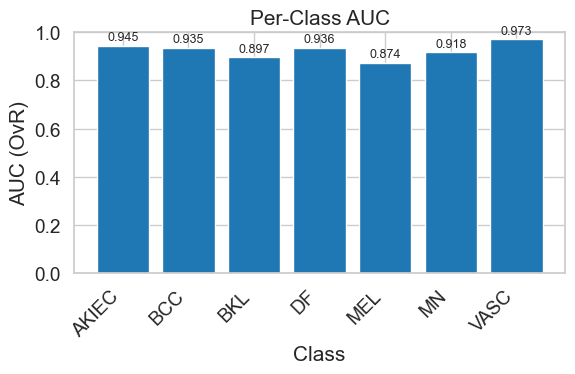

In [37]:
perclass_auc, confusion_matrix = evaluate_perclass(best_model_upper_bound, test_loader)
plot_perclass_auc(perclass_auc, list(short_labels.values()))

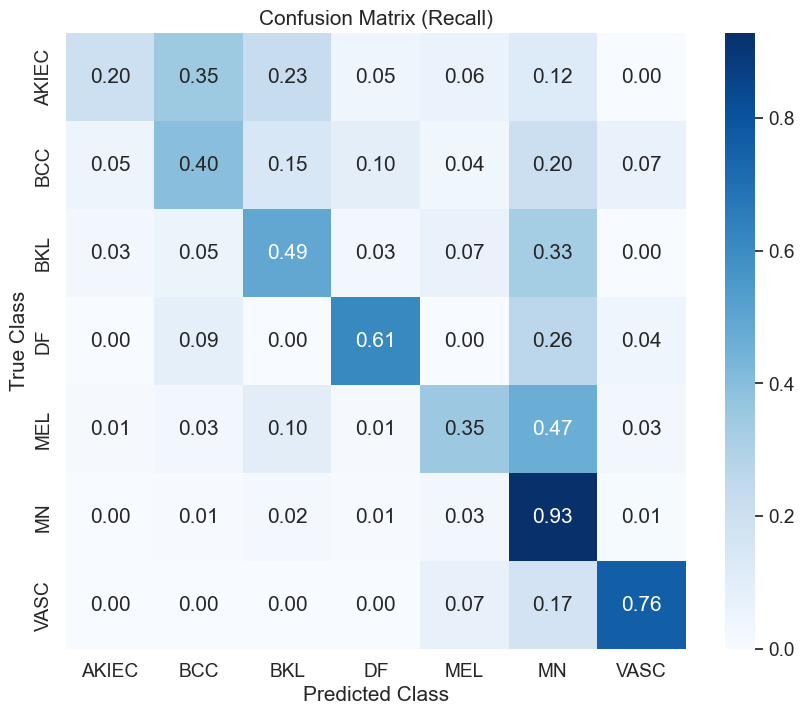

In [38]:
plot_per_class_recall(confusion_matrix, list(short_labels.values()))

## Create SSL versions of the dataset - start with 50% unlabeled rate

In [9]:
RANDOM_SEED = 42

In [10]:
# Create SSL versions of our datasets
unlabeled_rate = 0.5

# print(train_dataset.labels)
# print(train_dataset.imgs)
train_labels_ssl_50 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_50 = SSLDataset(train_dataset, train_labels_ssl_50)
train_ssl_loader_50 = data.DataLoader(train_ssl_dataset_50, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.5 | Total examples: 7007 | Labeled examples: 3506 | Unlabeled examples: 3501
Class 0: 114/228 labeled, 114 unlabeled
Class 1: 180/359 labeled, 179 unlabeled
Class 2: 385/769 labeled, 384 unlabeled
Class 3: 40/80 labeled, 40 unlabeled
Class 4: 390/779 labeled, 389 unlabeled
Class 5: 2347/4693 labeled, 2346 unlabeled
Class 6: 50/99 labeled, 49 unlabeled


In [ ]:
all_histories_cnn_50 = []
lrs = [0.0001, 0.001, 0.01]
l2_weights = [0.0, 0.001, 0.01]
taus = [0.5, 0.7, 0.8, 0.9, 0.95]

for lr in lrs:
    for l2 in l2_weights:
        for tau in taus:
            np.random.seed(RANDOM_SEED)
            torch.manual_seed(RANDOM_SEED)
            model, criterion, optimizer = default_setup_cnn(lr=lr, l2_weight=l2)
            model = model.to(device)
            history = train_loop_hard_pseudo_label(
                model, train_ssl_loader_50, val_loader, criterion, optimizer,
                num_epochs=20, threshold=tau, device=device)
            best_history = max(history, key=lambda x: x['val_auc_macro'])
            all_histories_cnn_50.append({
                "lr": lr,
                "l2": l2,
                "tau": tau,
                "history": history,
                "best_history": best_history,
            })
            print(f"Done {len(all_histories_cnn_50)} / {len(lrs)*len(l2_weights)*len(taus)}: lr={lr} | l2={l2} | tau={tau} | Val mAUC: {best_history['val_auc_macro']:.4f} | Val mNLL: {best_history['val_macro_nll']:.4f}")

In [11]:
# Ran above in colab GPU and saved results, so we can load them here
with open('results/cnn-baseline/all_histories_cnn_50.pkl', 'rb') as f:
    all_histories_cnn_50 = pickle.load(f)

In [12]:
for h in sorted(all_histories_cnn_50, key=lambda x: x['best_history']['val_auc_macro'], reverse=True):
    print(f"LR: {h['lr']} | L2 strength: {h['l2']} | Tau: {h['tau']} | Best Val AUC Macro: {h['best_history']['val_auc_macro']:.4f} | Val NLL Macro: {h['best_history']['val_macro_nll']:.4f} ")

LR: 0.001 | L2 strength: 0.0 | Tau: 0.9 | Best Val AUC Macro: 0.9174 | Val NLL Macro: 1.4885 
LR: 0.001 | L2 strength: 0.001 | Tau: 0.9 | Best Val AUC Macro: 0.9150 | Val NLL Macro: 1.5637 
LR: 0.001 | L2 strength: 0.001 | Tau: 0.5 | Best Val AUC Macro: 0.9150 | Val NLL Macro: 1.4741 
LR: 0.0001 | L2 strength: 0.001 | Tau: 0.8 | Best Val AUC Macro: 0.9136 | Val NLL Macro: 1.5784 
LR: 0.0001 | L2 strength: 0.0 | Tau: 0.8 | Best Val AUC Macro: 0.9135 | Val NLL Macro: 1.6010 
LR: 0.001 | L2 strength: 0.001 | Tau: 0.8 | Best Val AUC Macro: 0.9135 | Val NLL Macro: 1.5789 
LR: 0.001 | L2 strength: 0.001 | Tau: 0.95 | Best Val AUC Macro: 0.9133 | Val NLL Macro: 1.5261 
LR: 0.001 | L2 strength: 0.001 | Tau: 0.7 | Best Val AUC Macro: 0.9133 | Val NLL Macro: 1.4871 
LR: 0.0001 | L2 strength: 0.01 | Tau: 0.95 | Best Val AUC Macro: 0.9132 | Val NLL Macro: 1.6000 
LR: 0.001 | L2 strength: 0.0 | Tau: 0.7 | Best Val AUC Macro: 0.9131 | Val NLL Macro: 1.5741 
LR: 0.0001 | L2 strength: 0.01 | Tau: 0.7 

In [13]:
SEEDS = [42, 123, 145]
test_results_by_seed_cnn_50 = {}
for seed in SEEDS:
    np.random.seed(seed)
    torch.manual_seed(seed)
    tau, lr, l2 = 0.9, 0.001, 0.0
    model, criterion, optimizer = default_setup_cnn(lr=lr, l2_weight=l2)
    model = model.to(device)
    history = train_loop_hard_pseudo_label(
            model, train_ssl_loader_50, val_loader, criterion, optimizer,
            num_epochs=20, threshold=tau, device=device)
    best_history = max(history, key=lambda x: x['val_auc_macro'])
    best_model = CNN(n_channels, n_classes)
    best_model = best_model.to(device)
    best_model.load_state_dict(best_history['model_state'])
    test_results = evaluate(best_model, test_loader, device=device)
    test_results_by_seed_cnn_50[seed] = test_results

NameError: name 'device' is not defined

In [14]:
# Ran above in colab GPU and saved results to file
with open('results/cnn-baseline/test_results_by_seed_cnn_50.pkl', 'rb') as f:
    test_results_by_seed_cnn_50 = pickle.load(f)

In [15]:
print_aggregate_test_results(test_results_by_seed_cnn_50)

Test mAUC: 0.9027 ± 0.0024
Test mNLL: 1.7311 ± 0.0824
Test per-class NLL: [1.9175±0.1279  1.6663±0.1533  1.2041±0.0682  3.1415±0.2343  1.8703±0.1793  0.3065±0.0405  2.0117±0.4904]


### Trying 75% unlabeled rate

In [38]:
# Create SSL versions of our datasets
unlabeled_rate = 0.75

train_labels_ssl_75 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_75 = SSLDataset(train_dataset, train_labels_ssl_75)
train_ssl_loader_75 = data.DataLoader(train_ssl_dataset_75, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.75 | Total examples: 7007 | Labeled examples: 1754 | Unlabeled examples: 5253
Class 0: 57/228 labeled, 171 unlabeled
Class 1: 90/359 labeled, 269 unlabeled
Class 2: 193/769 labeled, 576 unlabeled
Class 3: 20/80 labeled, 60 unlabeled
Class 4: 195/779 labeled, 584 unlabeled
Class 5: 1174/4693 labeled, 3519 unlabeled
Class 6: 25/99 labeled, 74 unlabeled


### 90%

In [47]:
# Create SSL versions of our datasets
unlabeled_rate = 0.9

train_labels_ssl_90 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_90 = SSLDataset(train_dataset, train_labels_ssl_90)
train_ssl_loader_90 = data.DataLoader(train_ssl_dataset_90, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.9 | Total examples: 7007 | Labeled examples: 702 | Unlabeled examples: 6305
Class 0: 23/228 labeled, 205 unlabeled
Class 1: 36/359 labeled, 323 unlabeled
Class 2: 77/769 labeled, 692 unlabeled
Class 3: 8/80 labeled, 72 unlabeled
Class 4: 78/779 labeled, 701 unlabeled
Class 5: 470/4693 labeled, 4223 unlabeled
Class 6: 10/99 labeled, 89 unlabeled
